In [1]:
from __future__ import annotations

import operator
from typing import Annotated, TypedDict

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

In [2]:

# ----------------------------
# Structured Outputs
# ----------------------------

class SentimentOutput(BaseModel):
    sentiment: str = Field(description="positive, neutral, or negative")
    confidence: float


class KeywordsOutput(BaseModel):
    keywords: list[str]


class SummaryOutput(BaseModel):
    summary: str


In [3]:
# ----------------------------
# Graph State
# ----------------------------

class GraphState(TypedDict):
    text: str

    # Reducer merges outputs from parallel nodes
    results: Annotated[list[dict], operator.add]


# ----------------------------
# Parallel Nodes
# ----------------------------

def analyze_sentiment(state: GraphState):
    # Normally:
    # response = llm.with_structured_output(SentimentOutput).invoke(...)
    result = SentimentOutput(
        sentiment="positive",
        confidence=0.93,
    )

    return {
        "results": [{
            "task": "sentiment",
            "data": result.model_dump()
        }]
    }


def extract_keywords(state: GraphState):
    result = KeywordsOutput(
        keywords=["langgraph", "python", "workflow"]
    )

    return {
        "results": [{
            "task": "keywords",
            "data": result.model_dump()
        }]
    }


def summarize(state: GraphState):
    result = SummaryOutput(
        summary="A short summary of the input."
    )

    return {
        "results": [{
            "task": "summary",
            "data": result.model_dump()
        }]
    }

In [4]:
# ----------------------------
# Reducer / Aggregator
# ----------------------------

def aggregate(state: GraphState):
    output = {}

    for item in state["results"]:
        output[item["task"]] = item["data"]

    return output


In [5]:
# ----------------------------
# Build Graph
# ----------------------------

builder = StateGraph(GraphState)

builder.add_node("sentiment", analyze_sentiment)
builder.add_node("keywords", extract_keywords)
builder.add_node("summary", summarize)
builder.add_node("aggregate", aggregate)

# Fan out
builder.add_edge(START, "sentiment")
builder.add_edge(START, "keywords")
builder.add_edge(START, "summary")

# Fan in
builder.add_edge("sentiment", "aggregate")
builder.add_edge("keywords", "aggregate")
builder.add_edge("summary", "aggregate")

builder.add_edge("aggregate", END)

graph = builder.compile()



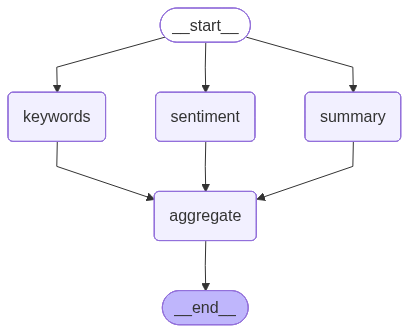

In [7]:
graph

In [6]:
# ----------------------------
# Run
# ----------------------------

result = graph.invoke({
    "text": "LangGraph makes it easy to build parallel AI workflows.",
    "results": [],
})

print(result)

{'text': 'LangGraph makes it easy to build parallel AI workflows.', 'results': [{'task': 'keywords', 'data': {'keywords': ['langgraph', 'python', 'workflow']}}, {'task': 'sentiment', 'data': {'sentiment': 'positive', 'confidence': 0.93}}, {'task': 'summary', 'data': {'summary': 'A short summary of the input.'}}]}
